In [3]:
!pip install opencv-python

In [4]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import accuracy_score

from PIL import Image
import io
import os
import glob
import base64
import cv2

In [187]:
mnist = pd.read_csv('mnist_test.csv')
mnist.head(6)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [188]:
class_248 = mnist[(mnist["label"] == 2) | (mnist["label"] == 4) | (mnist["label"] == 8)]
print(class_248.shape[0])
testclass = class_248.head(400)
testclass = testclass.reset_index(drop=True)
testclass.to_csv('class_248.csv',index=False)

2988


Aufloesung in DPI: 100.0
(10000, 785)
label: 4 höhe: 28 breite: 28


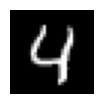

label: 4 höhe: 28 breite: 28


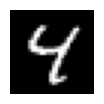

label: 4 höhe: 28 breite: 28


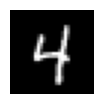

label: 4 höhe: 28 breite: 28


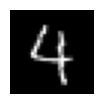

In [189]:
dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)

print(mnist.shape)
#print(mnist.values[0,1:])
for i in range(1,5):
    testbild = testclass.values[i,1:].reshape(28,28)
    testlabel = testclass.values[i,0]
    h, w = testbild.shape
    print("label: " + str(testlabel) + " höhe: " + str(h), "breite: " + str(w))
    plt.figure(figsize=(3*w / float(dpi), 3*h / float(dpi))).add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(testbild, cmap='gray')
    plt.show()

In [ ]:
!pip install scikit-image
import skimage
print(skimage.__version__)

Aufloesung in DPI: 100.0


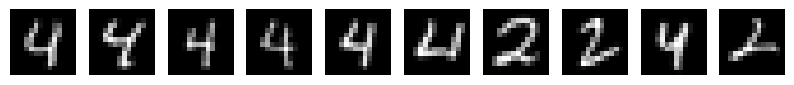

In [190]:
dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)
plt.figure(figsize = (10,4))

gesamtzahl = 10
for i in range(1,gesamtzahl+1):
    testbild = class_248.values[i,1:].reshape(28,28)
    testbild = testbild.astype(np.uint8)
    testlabel = class_248.values[i,0]
    
    img = Image.fromarray(testbild)
    img = img.resize((14,14))
    
    kleinesbild = np.asarray(img)
    kleinesbild = kleinesbild.astype(np.uint8)
    h, w = kleinesbild.shape
    kleinesarray = kleinesbild.flatten()
    
    #print(kleinesarray)
    string = "smn"+str(testlabel)+"_"+str(i)+".png"
    plt.subplot(1,gesamtzahl,i)
    plt.imshow(img)
       
    plt.axis('off')
    plt.gray()
    plt.imshow(kleinesbild, aspect=1, cmap='gray')
    plt.imsave(string, testbild, cmap='gray')
plt.show()

In [16]:
## Zur Erzeugung eines Test-Dataframes in Pandas, hat für das eigentliche Projekt keine Bedeutung
spaltennamen = ['label']
erstezeile = []
labelspalte = [66,33,44,11,55]
for i in range(10):
    spaltennamen.append("p"+str(i))
    
for j in range(5):
    erstezeile.append([labelspalte[j]])
    for i in range(10):
        erstezeile[j].append(i+j)
df = pd.DataFrame(erstezeile, columns=spaltennamen)
print(df.head(4))

   label  p0  p1  p2  p3  p4  p5  p6  p7  p8  p9
0     66   0   1   2   3   4   5   6   7   8   9
1     33   1   2   3   4   5   6   7   8   9  10
2     44   2   3   4   5   6   7   8   9  10  11
3     11   3   4   5   6   7   8   9  10  11  12


In [191]:
# Resizing der 28x28 Bilder auf 14x14. Dann werden die ersten 1000 Bilder in einer gesonderten CSV-Datei abgespeichert.
gesamtzahl = 1000

spaltennamen = ['label']
bildarray = []

for i in range(0, 196):
    spaltennamen.append("p"+str(i))


for i in range(gesamtzahl):
    bild = class_248.values[i,1:].reshape(28,28)
    bild = bild.astype(np.uint8)
    label = class_248.values[i,0]
    
    img = Image.fromarray(bild)
    img = img.resize((14,14))
    
    kleinesbild = np.asarray(img)
    kleinesbild = kleinesbild.astype(np.uint8)
    kleinesarray = kleinesbild.flatten()
    neuesarray = np.insert(kleinesarray, 0, label)
    
    if i==0:
        df = pd.DataFrame([neuesarray], columns=spaltennamen)
    if i>0:
        #df = df.append(pd.DataFrame([neuesarray], columns=spaltennamen), ignore_index = True)
        df = pd.concat([df, pd.DataFrame([neuesarray], columns=spaltennamen)])
    

#print(df.head(5))
print(df['label'].value_counts())
df.to_csv('class_248_14x14.csv',index=False)


4    346
2    343
8    311
Name: label, dtype: int64


Aufloesung in DPI: 100.0
label: 4 höhe: 14 breite: 14


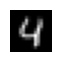

label: 4 höhe: 14 breite: 14


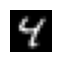

label: 4 höhe: 14 breite: 14


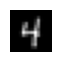

label: 4 höhe: 14 breite: 14


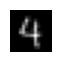

label: 4 höhe: 14 breite: 14


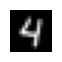

label: 4 höhe: 14 breite: 14


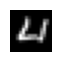

label: 2 höhe: 14 breite: 14


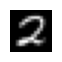

label: 2 höhe: 14 breite: 14


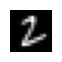

label: 4 höhe: 14 breite: 14


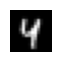

label: 2 höhe: 14 breite: 14


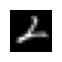

label: 2 höhe: 14 breite: 14


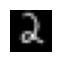

label: 4 höhe: 14 breite: 14


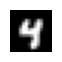

label: 4 höhe: 14 breite: 14


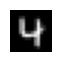

label: 4 höhe: 14 breite: 14


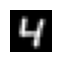

label: 8 höhe: 14 breite: 14


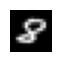

label: 4 höhe: 14 breite: 14


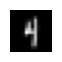

label: 4 höhe: 14 breite: 14


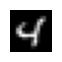

label: 2 höhe: 14 breite: 14


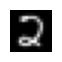

label: 2 höhe: 14 breite: 14


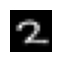

In [27]:
# Testblock: CSV mit 14x14-Bilder wird eingelesen und einige Bilder werden dargestellt.

m14x14 = pd.read_csv('class_248_14x14.csv')
m14x14.head(6)

dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)

for i in range(1,20):
    testbild = m14x14.values[i,1:].reshape(14,14)
    testlabel = m14x14.values[i,0]
    h, w = testbild.shape
    print("label: " + str(testlabel) + " höhe: " + str(h), "breite: " + str(w))
    plt.figure(figsize=(3*w / float(dpi), 3*h / float(dpi))).add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(testbild, cmap='gray', aspect=1)
    plt.show()

In [ ]:
# Ein 'üblicher' Decision-Tree-Algorithmus wird angewendet. Accuracy von ca, 85%. Für das Projekt unwesentlich
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

m14x14 = pd.read_csv('class_248_14x14.csv')
m14x14.head(6)

feature_spalten = []
for i in range(0, 196):
    feature_spalten.append("p"+str(i))

X = m14x14[feature_spalten]
y = m14x14['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

clf = DecisionTreeClassifier(random_state=42)
model = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))

fig = plt.figure(figsize=(20,20))
fig = tree.plot_tree(clf, feature_names=feature_spalten, class_names=['2','4','8'], filled=True, rounded=True)

In [192]:
# Hier findet das Training des Neuronalen Netzwerks statt.

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

m14x14 = pd.read_csv('class_248_14x14.csv')
m14x14.head(6)

feature_spalten = []
for i in range(0, 196):
    feature_spalten.append("p"+str(i))

X = m14x14[feature_spalten]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
y = m14x14['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # 70% training and 30% test

reg = MLPRegressor(hidden_layer_sizes = (100, 50, 2, 50, 100), 
                   activation = 'tanh', 
                   solver = 'adam', 
                   learning_rate_init = 0.001, 
                   max_iter = 1000, 
                   tol = 0.0000001, 
                   verbose = True)
reg.fit(X_train, X_train)

Iteration 1, loss = 0.05500979
Iteration 2, loss = 0.04045847
Iteration 3, loss = 0.03167167
Iteration 4, loss = 0.02685127
Iteration 5, loss = 0.02431427
Iteration 6, loss = 0.02291635
Iteration 7, loss = 0.02217838
Iteration 8, loss = 0.02176973
Iteration 9, loss = 0.02132655
Iteration 10, loss = 0.02083708
Iteration 11, loss = 0.02036821
Iteration 12, loss = 0.01991108
Iteration 13, loss = 0.01949783
Iteration 14, loss = 0.01912623
Iteration 15, loss = 0.01883961
Iteration 16, loss = 0.01859612
Iteration 17, loss = 0.01838406
Iteration 18, loss = 0.01823580
Iteration 19, loss = 0.01811018
Iteration 20, loss = 0.01801029
Iteration 21, loss = 0.01792357
Iteration 22, loss = 0.01785983
Iteration 23, loss = 0.01779976
Iteration 24, loss = 0.01775458
Iteration 25, loss = 0.01772682
Iteration 26, loss = 0.01769433
Iteration 27, loss = 0.01765531
Iteration 28, loss = 0.01763058
Iteration 29, loss = 0.01760539
Iteration 30, loss = 0.01759270
Iteration 31, loss = 0.01756923
Iteration 32, los

Iteration 263, loss = 0.01539851
Iteration 264, loss = 0.01539219
Iteration 265, loss = 0.01539268
Iteration 266, loss = 0.01539128
Iteration 267, loss = 0.01538046
Iteration 268, loss = 0.01536819
Iteration 269, loss = 0.01536036
Iteration 270, loss = 0.01534605
Iteration 271, loss = 0.01534317
Iteration 272, loss = 0.01533185
Iteration 273, loss = 0.01532791
Iteration 274, loss = 0.01530663
Iteration 275, loss = 0.01528990
Iteration 276, loss = 0.01529880
Iteration 277, loss = 0.01528336
Iteration 278, loss = 0.01527209
Iteration 279, loss = 0.01526537
Iteration 280, loss = 0.01524810
Iteration 281, loss = 0.01525855
Iteration 282, loss = 0.01523794
Iteration 283, loss = 0.01523393
Iteration 284, loss = 0.01521648
Iteration 285, loss = 0.01521433
Iteration 286, loss = 0.01520046
Iteration 287, loss = 0.01519395
Iteration 288, loss = 0.01517594
Iteration 289, loss = 0.01516175
Iteration 290, loss = 0.01514883
Iteration 291, loss = 0.01513833
Iteration 292, loss = 0.01513024
Iteration 

Iteration 521, loss = 0.01355532
Iteration 522, loss = 0.01354299
Iteration 523, loss = 0.01353677
Iteration 524, loss = 0.01354352
Iteration 525, loss = 0.01353333
Iteration 526, loss = 0.01353767
Iteration 527, loss = 0.01353555
Iteration 528, loss = 0.01352269
Iteration 529, loss = 0.01352691
Iteration 530, loss = 0.01351261
Iteration 531, loss = 0.01351991
Iteration 532, loss = 0.01352995
Iteration 533, loss = 0.01352116
Iteration 534, loss = 0.01353386
Iteration 535, loss = 0.01352333
Iteration 536, loss = 0.01351893
Iteration 537, loss = 0.01350392
Iteration 538, loss = 0.01350704
Iteration 539, loss = 0.01350028
Iteration 540, loss = 0.01349309
Iteration 541, loss = 0.01349469
Iteration 542, loss = 0.01349902
Iteration 543, loss = 0.01349036
Iteration 544, loss = 0.01347947
Iteration 545, loss = 0.01347260
Iteration 546, loss = 0.01347493
Iteration 547, loss = 0.01346403
Iteration 548, loss = 0.01346302
Iteration 549, loss = 0.01346465
Iteration 550, loss = 0.01345250
Iteration 

Iteration 776, loss = 0.01277335
Iteration 777, loss = 0.01276570
Iteration 778, loss = 0.01276808
Iteration 779, loss = 0.01275967
Iteration 780, loss = 0.01276421
Iteration 781, loss = 0.01276153
Iteration 782, loss = 0.01275262
Iteration 783, loss = 0.01275180
Iteration 784, loss = 0.01274901
Iteration 785, loss = 0.01275161
Iteration 786, loss = 0.01274596
Iteration 787, loss = 0.01274175
Iteration 788, loss = 0.01274485
Iteration 789, loss = 0.01273434
Iteration 790, loss = 0.01274667
Iteration 791, loss = 0.01274995
Iteration 792, loss = 0.01276031
Iteration 793, loss = 0.01273348
Iteration 794, loss = 0.01272191
Iteration 795, loss = 0.01271825
Iteration 796, loss = 0.01271261
Iteration 797, loss = 0.01271879
Iteration 798, loss = 0.01270907
Iteration 799, loss = 0.01272437
Iteration 800, loss = 0.01273837
Iteration 801, loss = 0.01272873
Iteration 802, loss = 0.01272194
Iteration 803, loss = 0.01272692
Iteration 804, loss = 0.01272065
Iteration 805, loss = 0.01271855
Iteration 

MLPRegressor(activation='tanh', hidden_layer_sizes=(100, 50, 2, 50, 100),
             max_iter=1000, tol=1e-07, verbose=True)

Aufloesung in DPI: 100.0


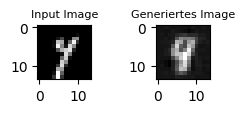

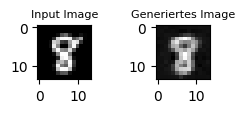

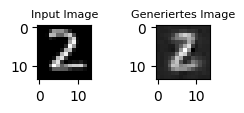

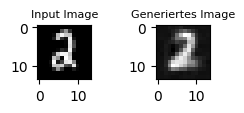

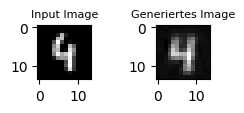

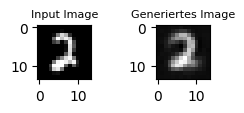

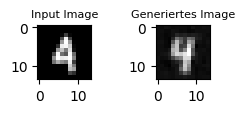

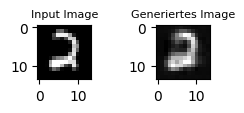

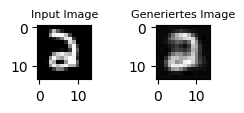

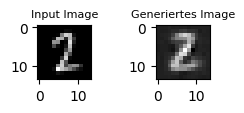

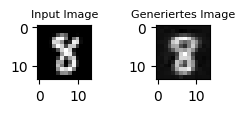

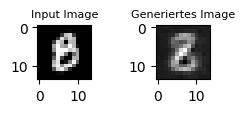

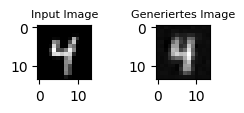

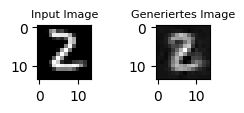

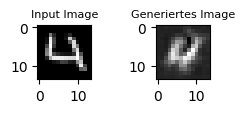

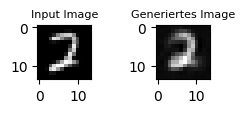

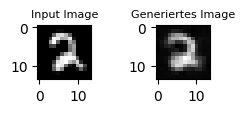

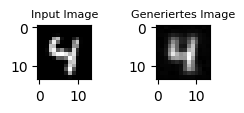

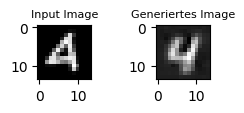

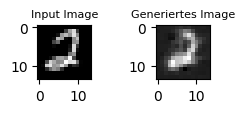

In [194]:
dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)

bilderzahl = 20

for i in range(0,bilderzahl):
    x_reconst = reg.predict(X_test[i].reshape(-1,196))
    plt.figure(figsize=(20*w / float(dpi), 5*h / float(dpi)))
    plt.subplot(1,2,1)
    plt.imshow(X_test[i].reshape(14,14), 'gray')
    plt.title('Input Image', fontsize = 8)
    plt.subplot(1,2,2)
    plt.imshow(x_reconst.reshape(14,14), 'gray')
    plt.title('Generiertes Image', fontsize = 8)
    plt.show()

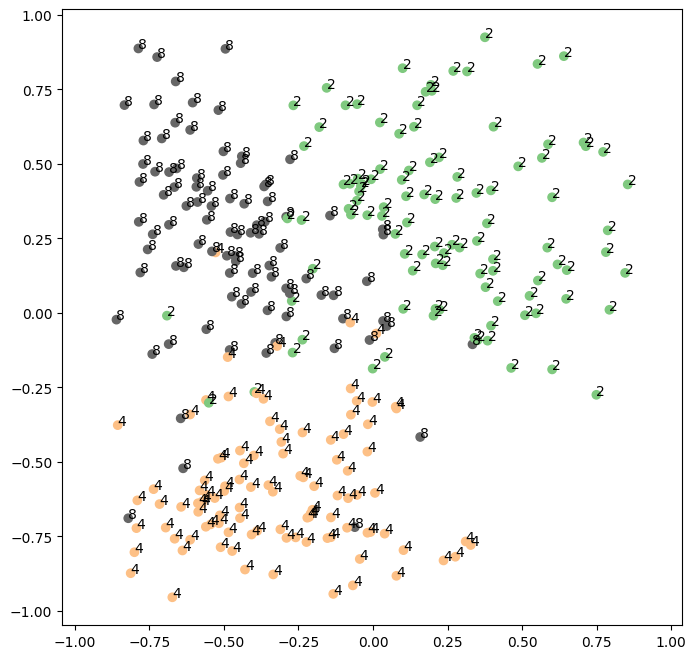

In [195]:
data = np.asmatrix(X_test)
encoder1 = data*reg.coefs_[0] + reg.intercepts_[0]
encoder1 = (np.exp(encoder1) - np.exp(-encoder1))/(np.exp(encoder1) + np.exp(-encoder1))

encoder2 = encoder1*reg.coefs_[1] + reg.intercepts_[1]
encoder2 = (np.exp(encoder2) - np.exp(-encoder2))/(np.exp(encoder2) + np.exp(-encoder2))
    
latent = encoder2*reg.coefs_[2] + reg.intercepts_[2]
latent = (np.exp(latent) - np.exp(-latent))/(np.exp(latent) + np.exp(-latent))

test_latent = np.asarray(latent)
latent_x_y = np.insert(test_latent, 2, y_test, axis = 1)

plt.figure(figsize = (8,8))
plt.scatter(latent_x_y[:,0],latent_x_y[:,1], c = latent_x_y[:,2], cmap = 'Accent')
plt.axis('equal')

for i, txt in enumerate(latent_x_y[:,2]):
    plt.annotate(np.uint8(txt), (latent_x_y[i,0], latent_x_y[i,1]))

plt.show()

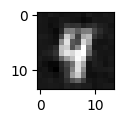

In [198]:
new_data = np.asmatrix([-0.4, -0.4])
decoder3 = new_data*reg.coefs_[3] + reg.intercepts_[3]

# Tangens-Hyperbolicus-Funktion: Anhand der Gewichtungen wird der Wert der Aktivierungsfunktion für Layer 3 berechnet.
decoder3 = (np.exp(decoder3) - np.exp(-decoder3))/(np.exp(decoder3) + np.exp(-decoder3))

# Tangens-Hyperbolicus-Funktion: Anhand der Gewichtungen wird der Wert der Aktivierungsfunktion für Layer 4 berechnet.
decoder4 = decoder3*reg.coefs_[4] + reg.intercepts_[4]
decoder4 = (np.exp(decoder4) - np.exp(-decoder4))/(np.exp(decoder4) + np.exp(-decoder4))

reconst = decoder4*reg.coefs_[5] + reg.intercepts_[5]
reconst = (np.exp(reconst) - np.exp(-reconst))/(np.exp(reconst) + np.exp(-reconst))

reconst = np.asarray(reconst)

testbild = reconst.reshape(14,14)
plt.figure(figsize = (1,1))
plt.imshow(testbild, cmap='gray', aspect=1)
plt.show()